In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/imdb_top_1000.csv')

print(df.head())
print(df.shape)
print(df.columns)

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

                         

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
print(df.columns)
print(df.shape)

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')
(1000, 16)


In [27]:
print(df.isnull().sum())

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64


In [28]:
print(df['IMDB_Rating'].describe())

count    1000.000000
mean        7.949300
std         0.275491
min         7.600000
25%         7.700000
50%         7.900000
75%         8.100000
max         9.300000
Name: IMDB_Rating, dtype: float64


In [29]:
print(df.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False).head(10))

Genre
Animation, Drama, War           8.50
Action, Sci-Fi                  8.40
Drama, Musical                  8.40
Drama, Mystery, War             8.35
Western                         8.35
Drama, Fantasy, Horror          8.30
Comedy, Musical, Romance        8.30
Crime, Drama, Music             8.30
Crime, Drama, Sci-Fi            8.30
Adventure, Mystery, Thriller    8.30
Name: IMDB_Rating, dtype: float64


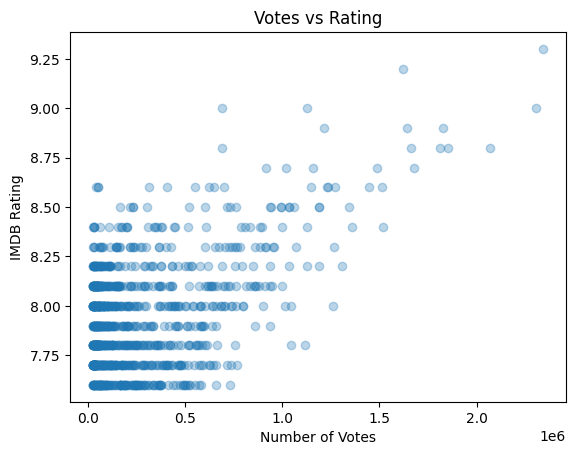

In [30]:
plt.scatter(df['No_of_Votes'], df['IMDB_Rating'], alpha=0.3)
plt.xlabel('Number of Votes')
plt.ylabel('IMDB Rating')
plt.title('Votes vs Rating')
plt.show()

In [31]:
print(df[['Series_Title', 'IMDB_Rating', 'Genre', 'Director']].sort_values('IMDB_Rating', ascending=False).head(10))

                                     Series_Title  IMDB_Rating  \
0                        The Shawshank Redemption          9.3   
1                                   The Godfather          9.2   
4                                    12 Angry Men          9.0   
2                                 The Dark Knight          9.0   
3                          The Godfather: Part II          9.0   
5   The Lord of the Rings: The Return of the King          8.9   
7                                Schindler's List          8.9   
6                                    Pulp Fiction          8.9   
8                                       Inception          8.8   
12                Il buono, il brutto, il cattivo          8.8   

                        Genre              Director  
0                       Drama        Frank Darabont  
1                Crime, Drama  Francis Ford Coppola  
4                Crime, Drama          Sidney Lumet  
2        Action, Crime, Drama     Christopher Nolan  
3  

In [32]:
df['Gross'] = df['Gross'].str.replace(',', '').astype(float)

df_model = df[['IMDB_Rating', 'No_of_Votes', 'Gross', 'Runtime', 'Meta_score']].dropna()

print(df_model.shape)
print(df_model.head())

(750, 5)
   IMDB_Rating  No_of_Votes        Gross  Runtime  Meta_score
0          9.3      2343110   28341469.0  142 min        80.0
1          9.2      1620367  134966411.0  175 min       100.0
2          9.0      2303232  534858444.0  152 min        84.0
3          9.0      1129952   57300000.0  202 min        90.0
4          9.0       689845    4360000.0   96 min        96.0


In [33]:
# Remove 'min' from Runtime and convert to number
df_model = df_model.copy()
df_model['Runtime'] = df_model['Runtime'].str.replace(' min', '').astype(int)

print(df_model.head())

   IMDB_Rating  No_of_Votes        Gross  Runtime  Meta_score
0          9.3      2343110   28341469.0      142        80.0
1          9.2      1620367  134966411.0      175       100.0
2          9.0      2303232  534858444.0      152        84.0
3          9.0      1129952   57300000.0      202        90.0
4          9.0       689845    4360000.0       96        96.0


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = df_model.drop('IMDB_Rating', axis=1)
y = df_model['IMDB_Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)

print(f"R2 Score: {r2:.2f}")

R2 Score: 0.55


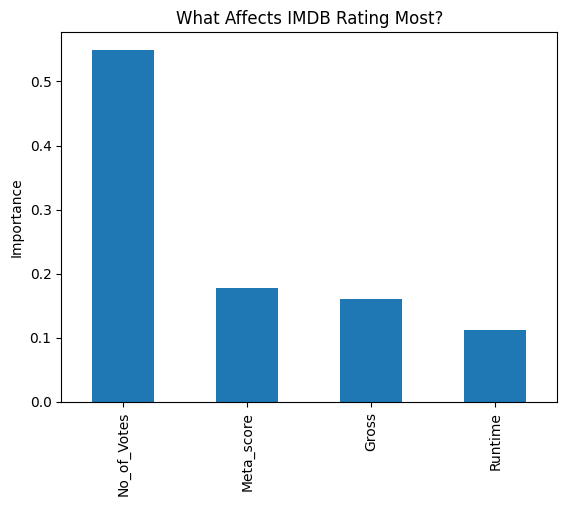

In [35]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar')
plt.title('What Affects IMDB Rating Most?')
plt.ylabel('Importance')
plt.show()

In [36]:
# High votes, high gross, long runtime, high metascore
movie = [[1800000, 500000000, 57, 90]]
predicted_rating = model.predict(movie)
print(f"Predicted IMDB Rating: {predicted_rating[0]:.1f}")

Predicted IMDB Rating: 8.7


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


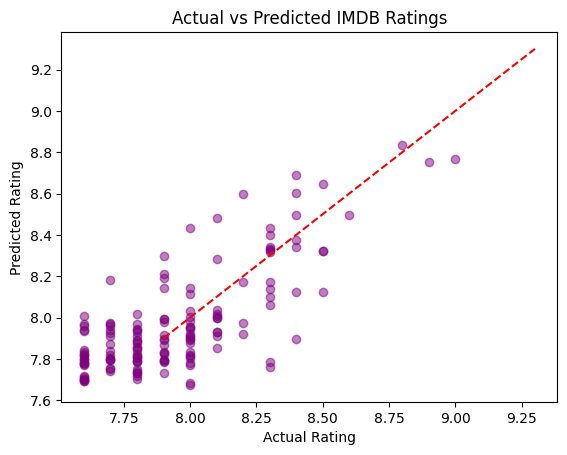

In [37]:
plt.scatter(y_test, predictions, alpha=0.5, color='purple')
plt.plot([7.9, 9.3], [7.9, 9.3], 'r--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted IMDB Ratings')
plt.show()

In [38]:
print(df.groupby('Director')['IMDB_Rating'].mean().sort_values(ascending=False).head())

Director
Frank Darabont        8.95
Lana Wachowski        8.70
Irvin Kershner        8.70
Masaki Kobayashi      8.60
Fernando Meirelles    8.60
Name: IMDB_Rating, dtype: float64
